# Replicating Ablation Results &mdash; *Evaluating Commercial AI Chatbots as News Intermediaries*

This companion notebook replicates the ablation studies from the raw evaluation logs.
It mirrors the conventions and visual style of `ReplicateResults.ipynb`
(provenance palette, Helvetica, slate-blue accent, etc.).

**Sections.**

1. **Web-search ablation** &mdash; search-enabled vs. baseline (no search), US & Canada.
2. **Adversarial robustness** &mdash; standard vs. false-premise accuracy on US & Canada.
3. **Pipeline validation (MC vs free-response)** &mdash; single-day paired evaluation graded by three independent
   LLM judges.
4. **Bonus: one-month-after temporal decay** &mdash; same questions, asked again 30 days later.

All figures are written to `figures_ablation/` as both `.pdf` and `.png`.


## 0. Setup

In [1]:
from __future__ import annotations  # Python 3.9 compatibility for `str | None` hints
import os, re, json, statistics, glob
from collections import defaultdict
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd()
RES  = ROOT / "results"
ABL  = ROOT / "ablation"

assert RES.is_dir() and ABL.is_dir(), "expected results/ and ablation/ at repo root"

REGIONS = [
    ("uscanada", "US & Canada"),
    ("afrique",  "Afrique"),
    ("arabic",   "Arabic"),
    ("hindi",    "Hindi"),
    ("russian",  "Russian"),
    ("turkce",   "Turkish"),
]
REGION_DIR_TO_NAME = dict(REGIONS)
REGION_NAMES = [n for _, n in REGIONS]

MAIN_MODELS = [
    ("gemini-3-flash-preview",     "Gemini 3 Flash",    "google"),
    ("gemini-3-pro-preview",       "Gemini 3 Pro",      "google"),
    ("grok-4-0709",                "Grok 4",            "xai"),
    ("claude-sonnet-4-5",          "Claude 4.5 Sonnet", "anthropic"),
    ("gpt-5-search-api",           "GPT-5",             "openai"),
    ("gpt-4o-mini-search-preview", "GPT-4o Mini",       "openai"),
]
MODEL_DIR_TO_NAME = {d: n for d, n, _ in MAIN_MODELS}
MODEL_NAMES = [n for _, n, _ in MAIN_MODELS]
PROVIDERS   = {n: p for _, n, p in MAIN_MODELS}

# Paired (search-enabled, no-search baseline) directories for the search ablation.
ABLATION_PAIRS = [
    ("Grok 4",            "grok-4-0709",          "grok-4-0709-baseline"),
    ("Claude 4.5 Sonnet", "claude-sonnet-4-5",    "claude-sonnet-4-5-baseline"),
    ("GPT-5",             "gpt-5-search-api",     "gpt-5.2-baseline"),
    ("Gemini 3 Pro",      "gemini-3-pro-preview", "gemini-3-pro-preview-baseline"),
]
ABLATION_MODELS = [m for m, _, _ in ABLATION_PAIRS]

# Adversarial study covers the same four frontier models on Feb 19-22 (US & Canada).
ADV_MODELS = [
    ("Grok 4",            "grok-4-0709"),
    ("Gemini 3 Pro",      "gemini-3-pro-preview"),
    ("Claude 4.5 Sonnet", "claude-sonnet-4-5"),
    ("GPT-5",             "gpt-5-search-api"),
]
ADV_DAYS = [f"february_{d}" for d in range(19, 23)]

# Free-response validation: a single April-6 day across 6 regions, 6 models, judged by 3 LLMs.
FR_MODELS = [
    ("Gemini 3 Pro",      "gemini-3-pro-preview"),
    ("Grok 4",            "grok-4-0709"),
    ("Gemini 3 Flash",    "gemini-3-flash-preview"),
    ("Claude 4.5 Sonnet", "claude-sonnet-4-5"),
    ("GPT-5",             "gpt-5-search-api"),
    ("GPT-4o Mini",       "gpt-4o-mini-search-preview"),
]
JUDGES = ["chatgpt", "claude", "gemini"]

# Convenience print for sanity check.
print("paths OK   |", ROOT)

paths OK   | <repo>


In [2]:
mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         8.0,
    "axes.linewidth":    0.5,
    "axes.edgecolor":    "#1F1F1D",
    "xtick.color":       "#888780",
    "ytick.color":       "#1F1F1D",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size":  2.0,
    "ytick.major.size":  0.0,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.10,
})

# Provenance palette (unchanged across all figures for coherence).
PAL = {
    "primary":    "#1F1F1D",
    "secondary":  "#9E9E99",
    "accent":       "#A63232",
    "accent_soft":  "#3F4D5A",   # slate blue for "non-native language" rows
    "accent_strong":"#A63232",   # kept for emphatic cases (e.g. Hindi bar)
    "text_main":  "#1F1F1D",
    "text_mid":   "#5F5E5A",
    "text_muted": "#888780",
    "grid":       (136/255, 135/255, 128/255, 0.12),
    "stripe":     "#F2EEE6",          # pale eggshell (alt-row stripes; warm-cool tension w/ slate accents)
    "provider": {
        "google":    "#3B5E9E",
        "xai":       "#1F1F1D",
        "anthropic": "#BE6642",
        "openai":    "#2A8D72",
    },
}

# Distinct *shape* per model so the eye can track a single series across
# the dumbbell and density-per-region plots. Colour encodes the provider,
# shape disambiguates the two models within a provider (e.g. Flash vs Pro).
MODEL_STYLE = {
    "Gemini 3 Flash":    dict(marker="o", color=PAL["provider"]["google"],    size=24),
    "Gemini 3 Pro":      dict(marker="^", color=PAL["provider"]["google"],    size=26),
    "Grok 4":            dict(marker="P", color=PAL["provider"]["xai"],       size=32),
    "Claude 4.5 Sonnet": dict(marker="D", color=PAL["provider"]["anthropic"], size=22),
    "GPT-5":             dict(marker="s", color=PAL["provider"]["openai"],    size=22),
    "GPT-4o Mini":       dict(marker="o", color=PAL["provider"]["openai"],    size=24),
}

def panel_header(ax, letter, title, subtitle):
    if letter:
        ax.text(0.0, 1.22, letter, transform=ax.transAxes,
                fontsize=9.5, fontweight="bold", fontstyle="italic",
                color=PAL["text_main"], ha="left", va="bottom")
        title_x = 0.085
    else:
        title_x = 0.0
    ax.text(title_x, 1.22, title, transform=ax.transAxes,
            fontsize=8.5, fontweight="bold",
            color=PAL["text_main"], ha="left", va="bottom")
    if subtitle:
        ax.text(0.0, 1.06, subtitle, transform=ax.transAxes,
                fontsize=7.0, color=PAL["text_mid"], ha="left", va="bottom")

def clean_spines(ax):
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", colors=PAL["text_muted"])

# Figures land in figures_ablation/ as both PDF and PNG.
FIG_DIR = ROOT / "figures_ablation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", transparent=True)
    fig.savefig(FIG_DIR / f"{stem}.png",
                dpi=400, transparent=False, facecolor="white")
    print("wrote", stem)

## 1. Helpers — answer extraction, citation extraction, judge parsing

In [3]:
# ── Canonical answer extractor ───────────────────────────────────────────
ANS_TAG_RE     = re.compile(r"<final_answer>(.*?)</final_answer>", re.IGNORECASE | re.DOTALL)
LETTER_PAREN   = re.compile(r"\(\s*([A-Fa-f])\s*\)")
LETTER_STRICT  = re.compile(r"^\s*\(?\s*([A-Fa-f])\s*\)?(?:\s|$|[\.,])")
LETTER_TAIL    = re.compile(r"\(\s*([A-Fa-f])\s*\)\s*$", re.MULTILINE)

def extract_answer(text: str | None) -> str | None:
    """Return the upper-case option letter (A-F) selected by the model.

    Same parsing behavior as the copy in ReplicateResults.ipynb. Inside
    the <final_answer> tag we prefer an explicit ``(X)`` token; fall
    back to a strict leading bare letter; otherwise return None. The
    earlier permissive regex spuriously extracted letters from refusal
    text such as the ``F`` in "Final answer:".
    """
    if not isinstance(text, str):
        return None
    m = ANS_TAG_RE.search(text)
    if m:
        inner = m.group(1)
        paren_matches = LETTER_PAREN.findall(inner)
        if paren_matches:
            return paren_matches[0].upper()
        m2 = LETTER_STRICT.match(inner.lstrip())
        if m2:
            return m2.group(1).upper()
        return None
    matches = LETTER_TAIL.findall(text)
    return matches[-1].upper() if matches else None


# ── Data-loading helpers ─────────────────────────────────────────────────
def load_jsonl(path):
    """Read a JSONL file into a list of dicts. Returns [] for missing files,
    so the ablation pipeline tolerates baseline cells with shorter day windows.
    """
    from pathlib import Path
    if not Path(path).is_file():
        return []
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]


# ── Gold-label errata (publicly documented corrections) ──────────────
# See ReplicateResults.ipynb for full provenance. Five gold labels in the
# original JSONL warrant correction; we apply them at load time so the
# on-disk data remains a faithful record while published numbers use the
# corrected gold. Multi-letter sets indicate duplicate-option questions
# where two option letters carry identical text and either is acceptable.
GOLD_ERRATA = {
    ("hindi",    "february_21", 19): {"C", "E"},  # dup (C)/(E) "237 ट्यूटर"
    ("afrique",  "february_9",  14): {"D", "E"},  # dup (D)/(E) "Pierre Robert"
    ("arabic",   "february_14", 20): "B",         # explanation quotes (B); gold was (A)
    ("uscanada", "february_13",  6): "A",         # gold was scaffolding-leak; (A) per explanation
}

def _gold_from_raw(s):
    s = (s or "").strip().strip("()").strip().upper()
    return s[0] if s and s[0] in "ABCDEF" else None

def gold_letter(row, *, region_dir=None, day=None, q_idx=None):
    """Normalize gold to A-F, a frozenset of letters, or None.

    When `region_dir`, `day`, `q_idx` are supplied and a matching erratum
    exists, returns the corrected gold; otherwise returns the first A-F
    letter in `row["correct_answer"]`.
    """
    key = (region_dir, day, q_idx) if region_dir is not None else None
    if key in GOLD_ERRATA:
        v = GOLD_ERRATA[key]
        return frozenset(v) if isinstance(v, (set, frozenset)) else v
    return _gold_from_raw(row.get("correct_answer"))

def is_correct_pred(pred, gold):
    """A pred is correct if it equals gold or is in the gold set (errata)."""
    if pred is None or gold is None:
        return False
    return pred in gold if isinstance(gold, frozenset) else pred == gold


_JUDGE_LINE = re.compile(r"^\s*(\d+)\.\s*(CORRECT|INCORRECT)\s*$", re.MULTILINE | re.IGNORECASE)
def parse_judge_txt(path):
    """Parse a free-response judge file (`N. CORRECT` / `N. INCORRECT` per
    line) and return a dict mapping 0-indexed q_idx → bool (True = correct).

    Returns {} if the file is missing — keeps the pipeline robust.
    """
    from pathlib import Path
    if not Path(path).is_file():
        return {}
    text = Path(path).read_text()
    out = {}
    for n, verdict in _JUDGE_LINE.findall(text):
        out[int(n) - 1] = (verdict.upper() == "CORRECT")
    return out


# `extract_answer` is duplicated verbatim across the three notebooks.
# The synthetic regression tests below break loudly if the regex changes.
assert extract_answer("<final_answer>A</final_answer>") == "A"
assert extract_answer("<final_answer>(B)</final_answer>") == "B"
assert extract_answer("<final_answer>  C  </final_answer>") == "C"
assert extract_answer("<final_answer>(D) An evil operative</final_answer>") == "D"
assert extract_answer("<final_answer>e</final_answer>") == "E"
assert extract_answer("<FINAL_ANSWER>F</FINAL_ANSWER>") == "F"
assert extract_answer("<final_answer>\n(A)\n</final_answer>") == "A"
assert extract_answer("Reasoning... (D)\nFinal: (A)") == "A"
assert extract_answer("I think it's A but maybe B") is None
assert extract_answer(None) is None
assert extract_answer("") is None
assert extract_answer("<final_answer></final_answer>") is None
assert extract_answer("<final_answer>G</final_answer>") is None
print("extract_answer parity-lock tests pass")


extract_answer parity-lock tests pass


## 2. Web-search ablation &mdash; search-enabled vs. no-search

We compute the ablation in two windows: the four-day window (Feb 19-22) that
time-aligns with the adversarial study, and the full 14-day window (Feb 9-22)
which gives tighter standard deviations. We also extend the ablation across
all six regions, since the no-search runs cover every region.


In [4]:
def build_ablation_records(regions=("uscanada",), days=None):
    """Yield per-question records for both search-enabled and baseline runs.

    Each record carries `condition ∈ {"search","no_search"}` so downstream aggregation can
    compute paired metrics with a single groupby.
    """
    if days is None:
        days = [f"february_{d}" for d in range(9, 23)]
    for r in regions:
        for name, search_dir, baseline_dir in ABLATION_PAIRS:
            for cond, dir_ in [("search", search_dir), ("no_search", baseline_dir)]:
                d = RES / r / dir_
                if not d.is_dir(): continue
                for day in days:
                    rows = load_jsonl(d / f"{day}_outputs.jsonl")
                    for q_idx, row in enumerate(rows):
                        pred = extract_answer(row.get("model_output"))
                        gold = gold_letter(row, region_dir=r, day=day, q_idx=q_idx)
                        yield {
                            "region_dir": r,
                            "region": REGION_DIR_TO_NAME[r],
                            "model":  name,
                            "condition": cond,
                            "day": day,
                            "q_idx": q_idx,
                            "predicted": pred,
                            "correct":  gold,
                            "is_correct": is_correct_pred(pred, gold),
                            "is_parseable": (pred is not None),
                        }

print("Building ablation DataFrame (US & Canada, 14 days x 2 conditions x 4 models)…")
df_abl = pd.DataFrame(build_ablation_records(regions=("uscanada",)))
print(f"  rows: {len(df_abl):,}")
df_abl.head()

Building ablation DataFrame (US & Canada, 14 days x 2 conditions x 4 models)…
  rows: 2,800


,region_dir,region,model,condition,day,q_idx,predicted,correct,is_correct,is_parseable
0,uscanada,US & Canada,Grok 4,search,february_9,0,A,A,True,True
1,uscanada,US & Canada,Grok 4,search,february_9,1,B,B,True,True
2,uscanada,US & Canada,Grok 4,search,february_9,2,C,C,True,True
3,uscanada,US & Canada,Grok 4,search,february_9,3,D,D,True,True
4,uscanada,US & Canada,Grok 4,search,february_9,4,E,E,True,True


In [5]:
def ablation_table(df, day_window=ADV_DAYS, label="Feb 19-22"):
    """Errors/25 search vs no-search, with Δ and no-search accuracy."""
    sub = df[df["day"].isin(day_window)]
    rows = []
    for m in ABLATION_MODELS:
        ms = sub[sub["model"] == m]
        # errors per day (out of 25)
        s_errs = (ms[ms["condition"] == "search"]
                  .groupby("day").apply(lambda g: (~g["is_correct"]).sum()).values)
        n_errs = (ms[ms["condition"] == "no_search"]
                  .groupby("day").apply(lambda g: (~g["is_correct"]).sum()).values)
        # parse-validity for the no-search run (Grok-4 baseline occasionally refuses)
        valid = ms[ms["condition"] == "no_search"]["is_parseable"].mean() * 25  # avg per 25
        # No-search accuracy among VALID responses only.
        v = ms[(ms["condition"] == "no_search") & (ms["is_parseable"])]
        ns_acc_valid = v["is_correct"].mean() * 100 if len(v) else float("nan")
        ns_acc_all   = ms[ms["condition"] == "no_search"]["is_correct"].mean() * 100
        rows.append(dict(
            model=m,
            search_err=s_errs.mean(),
            search_sd=s_errs.std(ddof=1) if len(s_errs)>1 else 0,
            nosearch_err=n_errs.mean(),
            nosearch_sd=n_errs.std(ddof=1) if len(n_errs)>1 else 0,
            delta=n_errs.mean() - s_errs.mean(),
            nosearch_valid=valid,
            nosearch_acc_valid=ns_acc_valid,
            nosearch_acc_all=ns_acc_all,
        ))
    out = pd.DataFrame(rows).set_index("model")
    out = out.loc[["Grok 4", "Claude 4.5 Sonnet", "GPT-5", "Gemini 3 Pro"]]
    out = out.round(2)
    print(f"\nWeb-search ablation, US & Canada, {label}")
    return out

tbl9_paper_window = ablation_table(df_abl, ADV_DAYS, "Feb 19-22")
display(tbl9_paper_window)

tbl9_full = ablation_table(df_abl, [f"february_{d}" for d in range(9,23)], "Feb 9-22 (full 14-day)")
display(tbl9_full)


Web-search ablation, US & Canada, Feb 19-22


,search_err,search_sd,nosearch_err,nosearch_sd,delta,nosearch_valid,nosearch_acc_valid,nosearch_acc_all
model,,,,,,,,
Grok 4,1.0,0.00,11.75,3.30,10.75,23.75,55.79,53.0
Claude 4.5 Sonnet,2.0,1.83,9.75,1.26,7.75,23.75,64.21,61.0
GPT-5,3.0,2.00,9.25,2.63,6.25,25.00,63.00,63.0
Gemini 3 Pro,1.0,0.82,10.00,2.16,9.00,23.00,65.22,60.0



Web-search ablation, US & Canada, Feb 9-22 (full 14-day)


,search_err,search_sd,nosearch_err,nosearch_sd,delta,nosearch_valid,nosearch_acc_valid,nosearch_acc_all
model,,,,,,,,
Grok 4,0.79,0.89,12.21,3.29,11.43,23.14,55.25,51.14
Claude 4.5 Sonnet,1.07,1.49,10.57,2.17,9.50,23.14,62.35,57.71
GPT-5,2.86,1.66,10.50,3.11,7.64,25.00,58.00,58.00
Gemini 3 Pro,1.00,0.96,9.86,2.21,8.86,23.00,65.84,60.57


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_websearch_ablation_dumbbell


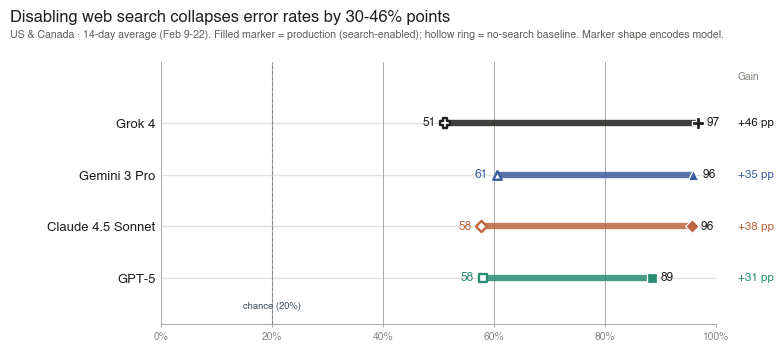

In [6]:
def plot_ablation_dumbbell(window_days=ADV_DAYS, title_suffix="Feb 19-22"):
    """Per-model search → no-search dumbbell with provenance-deck styling.

    Filled marker (per-model shape) = production (search-enabled);
    hollow ring of the same shape = no-search baseline.
    """
    sub = df_abl[df_abl["day"].isin(window_days)]
    rows = []
    for m in ABLATION_MODELS:
        ms = sub[sub["model"] == m]
        s_acc = ms[ms["condition"] == "search"   ]["is_correct"].mean() * 100
        n_acc = ms[ms["condition"] == "no_search"]["is_correct"].mean() * 100
        rows.append((m, s_acc, n_acc))
    rows.sort(key=lambda r: r[1], reverse=True)

    fig, ax = plt.subplots(figsize=(8.4, 3.6))
    y_idx = np.arange(len(rows))[::-1]
    trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

    for yi, (m, s_acc, n_acc) in zip(y_idx, rows):
        c     = PAL["provider"][PROVIDERS[m]]
        style = MODEL_STYLE[m]

        ax.plot([0, 100], [yi, yi], color=PAL["secondary"], linewidth=1.0, alpha=0.30, zorder=1)
        ax.plot([n_acc, s_acc], [yi, yi], color=c, linewidth=4.6,
                alpha=0.85, solid_capstyle="butt", zorder=2)

        ax.scatter([s_acc], [yi], s=style["size"]*2.2, color=c,
                   marker=style["marker"], edgecolors="white",
                   linewidths=0.9, zorder=4)
        ax.scatter([n_acc], [yi], s=style["size"]*1.45, facecolors="white",
                   edgecolors=c, marker=style["marker"], linewidths=1.7, zorder=3)

        ax.text(n_acc - 1.6, yi, f"{n_acc:.0f}", ha="right", va="center",
                fontsize=8.6, color=c, fontweight="bold")
        ax.text(s_acc + 1.6, yi, f"{s_acc:.0f}", ha="left", va="center",
                fontsize=8.6, color=PAL["text_main"], fontweight="bold")

        ax.text(1.04, yi, f"+{s_acc-n_acc:.0f} pp", transform=trans,
                ha="left", va="center", fontsize=8.4, fontweight="bold", color=c)

    ax.text(1.04, len(rows) - 0.2, "Gain", transform=trans,
            ha="left", va="bottom", fontsize=7.4, fontweight="bold", color=PAL["text_muted"])

    ax.set_yticks(y_idx)
    ax.set_yticklabels([m for m, *_ in rows], fontsize=9.4, fontweight=600,
                       color=PAL["text_main"])
    ax.tick_params(axis="y", length=0, pad=4)

    ax.axvline(20, color=PAL["accent_soft"], linewidth=0.8, linestyle=(0,(3,2)),
               alpha=0.7, zorder=0)
    ax.text(20, -0.55, "chance (20%)", ha="center", va="center",
            fontsize=6.8, color=PAL["accent_soft"], fontstyle="italic")

    ax.set_xlim(0, 100); ax.set_ylim(-0.9, len(rows) + 0.2)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 20, 40, 60, 80, 100]], fontsize=7.4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)

    fig.text(0.02, 0.97, "Disabling web search collapses error rates by 30-46% points",
             fontsize=11.8, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.925,
             f"US & Canada · {title_suffix}. "
             "Filled marker = production (search-enabled); hollow ring = no-search baseline. "
             "Marker shape encodes model.",
             fontsize=7.6, color=PAL["text_mid"])

    fig.subplots_adjust(left=0.20, right=0.86, top=0.86, bottom=0.13)
    savefig(fig, "fig_websearch_ablation_dumbbell")
    plt.show()

plot_ablation_dumbbell(
    window_days=[f"february_{d}" for d in range(9, 23)],
    title_suffix="14-day average (Feb 9-22)"
)


Loading cross-region ablation data (6 regions × 4 model pairs × 14 days)…
  rows: 16,308


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_websearch_ablation_by_region


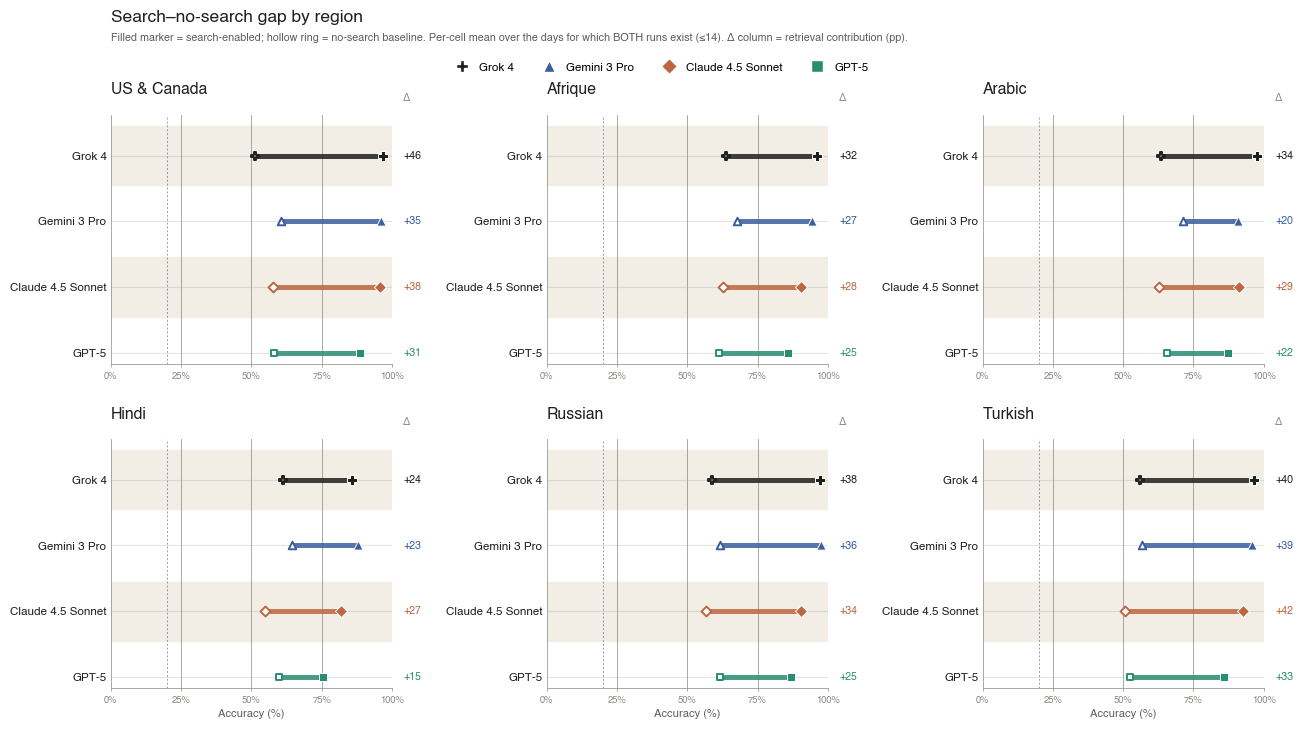

In [7]:
print("Loading cross-region ablation data (6 regions × 4 model pairs × 14 days)…")
df_abl_all = pd.DataFrame(build_ablation_records(regions=tuple(r for r,_ in REGIONS)))
print(f"  rows: {len(df_abl_all):,}")

def plot_ablation_by_region():
    """2×3 small-multiples: per-region search→no-search dumbbell.

    Same model order in every panel (sorted by overall search accuracy across regions),
    so y-tick labels never run into the previous panel's Δ column.
    """
    # Fixed model order across panels — by overall search-enabled accuracy
    overall = (df_abl_all[df_abl_all["condition"]=="search"]
               .groupby("model")["is_correct"].mean().sort_values(ascending=False))
    fixed_order = [m for m in overall.index if m in ABLATION_MODELS]

    fig = plt.figure(figsize=(13.0, 7.4))
    gs  = fig.add_gridspec(2, 3, left=0.078, right=0.965, top=0.86, bottom=0.085,
                           wspace=0.55, hspace=0.30)
    axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]

    for ax, region in zip(axes, REGION_NAMES):
        y_idx = np.arange(len(fixed_order))[::-1]

        for yi in y_idx[::2]:
            ax.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)

        trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

        for yi, m in zip(y_idx, fixed_order):
            sub = df_abl_all[(df_abl_all["model"]==m) & (df_abl_all["region"]==region)]
            if sub.empty: continue
            # Pair days per (region, model): a day counts only if BOTH the
            # search-enabled and no-search runs have rows on it. Without this,
            # cells whose baseline run was shorter than the 14-day search window
            # (e.g., grok-4-0709-baseline on Hindi/Russian/Türkçe) silently
            # average over different denominators and inflate the search-side
            # number relative to the no-search-side.
            sd = set(sub.loc[sub["condition"]=="search",    "day"])
            nd = set(sub.loc[sub["condition"]=="no_search", "day"])
            paired_days = sd & nd
            if not paired_days:
                continue
            sub = sub[sub["day"].isin(paired_days)]
            s     = sub[sub["condition"] == "search"   ]["is_correct"].mean() * 100
            n     = sub[sub["condition"] == "no_search"]["is_correct"].mean() * 100
            c     = PAL["provider"][PROVIDERS[m]]
            style = MODEL_STYLE[m]

            ax.plot([0, 100], [yi, yi], color=PAL["secondary"],
                    linewidth=0.8, alpha=0.28, zorder=1)
            ax.plot([n, s], [yi, yi], color=c, linewidth=3.6,
                    alpha=0.85, solid_capstyle="butt", zorder=2)
            ax.scatter([s], [yi], s=style["size"]*1.7, color=c,
                       marker=style["marker"], edgecolors="white",
                       linewidths=0.7, zorder=4)
            ax.scatter([n], [yi], s=style["size"]*1.15, facecolors="white",
                       edgecolors=c, marker=style["marker"], linewidths=1.4, zorder=3)
            ax.text(1.04, yi, f"+{s-n:.0f}", transform=trans,
                    ha="left", va="center", fontsize=7.6,
                    fontweight="bold", color=c)

        # Δ column header — blended transform so y is in DATA coords.
        ax.text(1.04, len(fixed_order) - 0.2, "Δ", transform=trans,
                ha="left", va="bottom", fontsize=7.4, fontweight="bold",
                color=PAL["text_muted"])

        ax.set_yticks(y_idx)
        ax.set_yticklabels(fixed_order, fontsize=8.4, fontweight=600,
                           color=PAL["text_main"])
        ax.tick_params(axis="y", length=0, pad=3)
        ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_xticklabels([f"{x}%" for x in [0, 25, 50, 75, 100]], fontsize=6.8)
        ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
        ax.set_axisbelow(True); clean_spines(ax)
        ax.axvline(20, color=PAL["accent_soft"], linewidth=0.7,
                   linestyle=(0,(2,2)), alpha=0.55, zorder=0)
        ax.text(0.0, 1.07, region, transform=ax.transAxes,
                fontsize=11.4, fontweight="bold", color=PAL["text_main"],
                ha="left", va="bottom")

    for ax in axes[3:]:
        ax.set_xlabel("Accuracy (%)", fontsize=8.0, color=PAL["text_mid"], labelpad=3)

    handles = [
        plt.Line2D([0],[0], marker=MODEL_STYLE[m]["marker"], linestyle="",
                   color=PAL["provider"][PROVIDERS[m]],
                   markeredgecolor="white", markersize=8, label=m)
        for m in fixed_order
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.945),
               ncol=4, frameon=False, fontsize=8.4,
               handletextpad=0.45, columnspacing=2.0)

    fig.text(0.078, 0.985, "Search–no-search gap by region",
             fontsize=12.5, fontweight="bold", color=PAL["text_main"])
    fig.text(0.078, 0.96,
             "Filled marker = search-enabled; hollow ring = no-search baseline. "
             "Per-cell mean over the days for which BOTH runs exist (≤14). "
             "Δ column = retrieval contribution (pp).",
             fontsize=7.8, color=PAL["text_mid"])

    savefig(fig, "fig_websearch_ablation_by_region")
    plt.show()

plot_ablation_by_region()


## 3. Adversarial robustness

§4.4 reports US & Canada × four-day standard vs. adversarial accuracy on four frontier models. We
re-derive Table 7 directly from `ablation/adversarial_questions_results/uscanada/`. Standard accuracies
come from the production run (`results/uscanada/<model>/`) over the same Feb 19-22 window so the
*Drop* column is computed on identical questions.

In [8]:
def build_standard_records(model_dirs, days):
    for d in days:
        for label, dir_ in model_dirs:
            rows = load_jsonl(RES / "uscanada" / dir_ / f"{d}_outputs.jsonl")
            for q_idx, r in enumerate(rows):
                pred = extract_answer(r.get("model_output"))
                gold = gold_letter(r, region_dir="uscanada", day=d, q_idx=q_idx)
                yield dict(model=label, day=d, predicted=pred, correct=gold,
                           is_correct=is_correct_pred(pred, gold))

def build_adversarial_records(model_dirs, days):
    # Adversarial questions are NOT in the gold-errata set (they are a separate
    # question pool with their own gold labels), so the errata lookup is a
    # no-op here; pass q_idx anyway for symmetry.
    for d in days:
        for label, dir_ in model_dirs:
            rows = load_jsonl(ABL / "adversarial_questions_results" / "uscanada" / dir_ / f"{d}_outputs.jsonl")
            for q_idx, r in enumerate(rows):
                pred = extract_answer(r.get("model_output"))
                gold = gold_letter(r)  # adversarial pool: no errata
                yield dict(model=label, day=d, predicted=pred, correct=gold,
                           is_correct=is_correct_pred(pred, gold))

df_std = pd.DataFrame(build_standard_records(ADV_MODELS, ADV_DAYS))
df_adv = pd.DataFrame(build_adversarial_records(ADV_MODELS, ADV_DAYS))
print(f"std rows: {len(df_std):,}   adv rows: {len(df_adv):,}")

def adv_table():
    """Reproduce Table 7: standard errors / adversarial errors / adv accuracy / drop."""
    out = []
    for m, _ in ADV_MODELS:
        s = df_std[df_std["model"]==m]
        a = df_adv[df_adv["model"]==m]
        s_errs = s.groupby("day").apply(lambda g: (~g["is_correct"]).sum()).values
        a_errs = a.groupby("day").apply(lambda g: (~g["is_correct"]).sum()).values
        s_acc  = s["is_correct"].mean() * 100
        a_acc  = a["is_correct"].mean() * 100
        out.append(dict(
            model=m,
            std_err=s_errs.mean(),
            std_sd=s_errs.std(ddof=1),
            adv_err=a_errs.mean(),
            adv_sd=a_errs.std(ddof=1),
            std_acc=s_acc,
            adv_acc=a_acc,
            drop=s_acc - a_acc,
        ))
    return pd.DataFrame(out).set_index("model").round(2)

t7 = adv_table()
print("\nStandard vs. adversarial (Feb 19-22, US & Canada).")
display(t7)

std rows: 400   adv rows: 400

Standard vs. adversarial (Feb 19-22, US & Canada).


,std_err,std_sd,adv_err,adv_sd,std_acc,adv_acc,drop
model,,,,,,,
Grok 4,1.0,0.00,7.50,1.73,96.0,70.0,26.0
Gemini 3 Pro,1.0,0.82,11.25,3.86,96.0,55.0,41.0
Claude 4.5 Sonnet,2.0,1.83,13.50,1.29,92.0,46.0,46.0
GPT-5,3.0,2.00,20.25,1.71,88.0,19.0,69.0


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_standard_vs_adversarial_replicated


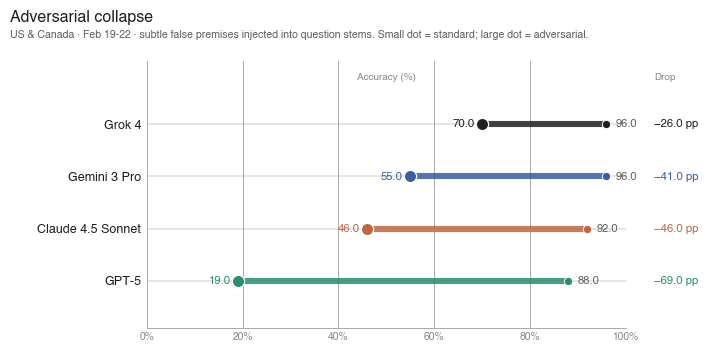

In [9]:
def plot_standard_vs_adversarial_replicated(t7):
    """Plot standard vs. adversarial accuracy directly from the data."""
    adv = t7.sort_values("adv_acc", ascending=False).copy()

    fig, ax = plt.subplots(figsize=(7.6, 3.6))
    y = np.arange(len(adv))[::-1]
    for yi, model in zip(y, adv.index):
        std  = adv.loc[model, "std_acc"]
        a    = adv.loc[model, "adv_acc"]
        c    = PAL["provider"][PROVIDERS[model]]
        ax.plot([0, 100], [yi, yi], color=PAL["secondary"], linewidth=1.1,
                alpha=0.35, zorder=1)
        ax.plot([a, std], [yi, yi], color=c, linewidth=4.4,
                alpha=0.85, solid_capstyle="butt", zorder=2)
        ax.scatter([std], [yi], s=36, color=c, edgecolors="white", linewidths=0.7, zorder=3)
        ax.scatter([a],   [yi], s=78, color=c, edgecolors="white", linewidths=0.9, zorder=3)
        ax.text(std + 2.0, yi, f"{std:.1f}", va="center", ha="left",
                fontsize=8.0, color=PAL["text_mid"], fontweight="bold")
        ax.text(a - 1.5, yi, f"{a:.1f}", va="center", ha="right",
                fontsize=8.2, color=c, fontweight="bold")

    ax.set_yticks(y); ax.set_yticklabels(adv.index, fontsize=9,
                                          color=PAL["text_main"], fontweight=600)
    ax.tick_params(axis="y", length=0, pad=4)

    trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(1.06, len(adv) - 0.2, "Drop", transform=trans, ha="left", va="bottom",
            fontsize=7.2, fontweight="bold", color=PAL["text_muted"])
    for yi, model in zip(y, adv.index):
        drop = adv.loc[model, "drop"]
        c = PAL["provider"][PROVIDERS[model]]
        ax.text(1.06, yi, f"−{drop:.1f} pp", transform=trans, ha="left", va="center",
                fontsize=8.2, color=c, fontweight="bold")

    ax.text(50, len(adv) - 0.2, "Accuracy (%)", ha="center", va="bottom",
            fontsize=7.2, fontweight="bold", color=PAL["text_muted"])

    ax.set_xlim(0, 100); ax.set_ylim(-0.9, len(adv) + 0.2)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 20, 40, 60, 80, 100]], fontsize=7.4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top","right","left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="x", length=0, pad=3)

    fig.text(0.02, 0.97, "Adversarial collapse",
             fontsize=11.5, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.925,
             "US & Canada · Feb 19-22 · subtle false premises injected into question stems. "
             "Small dot = standard; large dot = adversarial.",
             fontsize=7.6, color=PAL["text_mid"])

    fig.subplots_adjust(left=0.20, right=0.83, top=0.86, bottom=0.12)
    savefig(fig, "fig_standard_vs_adversarial_replicated")
    plt.show()

plot_standard_vs_adversarial_replicated(t7)

Detection vs. accuracy:


,Detection rate (%),Adv. acc. (%)
model,,
Grok 4,59,70.0
Gemini 3 Pro,80,55.0
Claude 4.5 Sonnet,78,46.0
GPT-5,36,19.0


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_detection_vs_accuracy_replicated


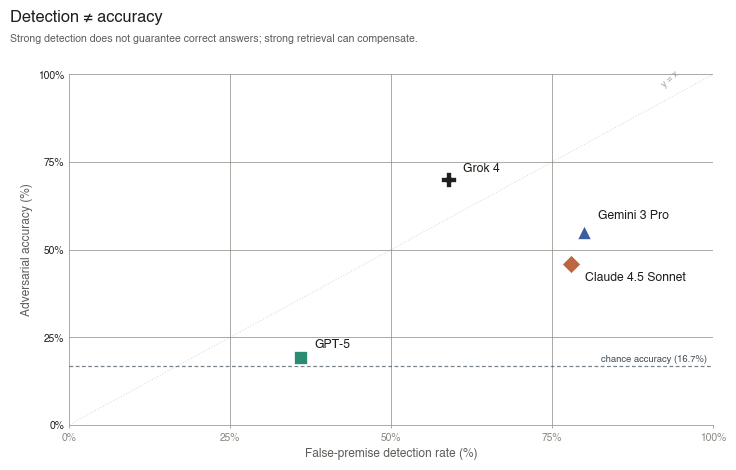

In [10]:
#  False-premise detection vs. adversarial accuracy.
# Per-question detection labels are not in the JSONL files (those came from a
# manual / LLM-judge pass over the model_output text). We pair the published
# detection rates with the adversarial accuracies computed above.
detection_paper = {
    "Gemini 3 Pro":      80,
    "Claude 4.5 Sonnet": 78,
    "Grok 4":            59,
    "GPT-5":             36,
}
t8 = pd.DataFrame({
    "Detection rate (%)": [detection_paper[m] for m in t7.index],
    "Adv. acc. (%)":      t7["adv_acc"].values,
}, index=t7.index).round(2)
print("Detection vs. accuracy:")
display(t8)

def plot_detection_vs_accuracy(t8):
    """Detection-rate × accuracy scatter with provider-colored, model-shape markers,
    chance-line annotation, y=x reference, and stagger-aware label placement."""
    fig, ax = plt.subplots(figsize=(7.4, 4.8))

    # y=x reference (background)
    ax.plot([0, 100], [0, 100], color=PAL["secondary"], linewidth=0.8,
            alpha=0.35, linestyle=":", zorder=1)
    ax.text(95, 96, "y = x", fontsize=6.6, color=PAL["secondary"],
            rotation=42, ha="right", va="bottom", fontstyle="italic")
    # chance accuracy line (six-option adversarial set: 1/6 ≈ 16.7%)
    ax.axhline(100/6, color=PAL["accent_soft"], linewidth=0.9, linestyle=(0,(3,2)),
               alpha=0.70, zorder=1)
    ax.text(99, 100/6 + 1.4, "chance accuracy (16.7%)", color=PAL["accent_soft"],
            fontsize=6.8, fontstyle="italic", ha="right")

    # Stagger labels so they never collide with markers or each other
    label_offsets = {
        "Grok 4":            ( 10,   6),   # right of marker
        "Gemini 3 Pro":      ( 10,  10),   # above-right
        "Claude 4.5 Sonnet": ( 10, -12),   # below-right (avoids Gemini Pro)
        "GPT-5":             (  10,  8),   # right of marker
    }

    for m in t8.index:
        x = t8.loc[m, "Detection rate (%)"]
        y = t8.loc[m, "Adv. acc. (%)"]
        c     = PAL["provider"][PROVIDERS[m]]
        style = MODEL_STYLE[m]
        ax.scatter([x], [y], s=style["size"]*4.5, color=c,
                   marker=style["marker"], edgecolors="white", linewidths=1.2, zorder=4)
        dx, dy = label_offsets.get(m, (8, 6))
        ha = "left" if dx > 0 else "right"
        ax.annotate(m, (x, y), xytext=(dx, dy), textcoords="offset points",
                    fontsize=8.8, color=PAL["text_main"], fontweight=600, ha=ha)

    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100]); ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 25, 50, 75, 100]], fontsize=7.4)
    ax.set_yticklabels([f"{x}%" for x in [0, 25, 50, 75, 100]], fontsize=7.4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)
    ax.set_xlabel("False-premise detection rate (%)",
                  fontsize=8.6, color=PAL["text_mid"], labelpad=4)
    ax.set_ylabel("Adversarial accuracy (%)",
                  fontsize=8.6, color=PAL["text_mid"], labelpad=4)

    fig.text(0.02, 0.97, "Detection ≠ accuracy", fontsize=11.8,
             fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.928,
             "Strong detection does not guarantee correct answers; strong retrieval can compensate.",
             fontsize=7.6, color=PAL["text_mid"])
    fig.subplots_adjust(left=0.10, right=0.97, top=0.86, bottom=0.13)
    savefig(fig, "fig_detection_vs_accuracy_replicated")
    plt.show()

plot_detection_vs_accuracy(t8)


## 4. Pipeline validation &mdash; MC vs. free-response (April 6, 2026)

A single-day paired evaluation: every question was posed twice &mdash; once in MC form and once
in FR form &mdash; and the FR responses were graded by three independent LLM judges (ChatGPT, Claude, Gemini).
We rebuild the MC vs FR summary and the Fleiss-κ inter-judge agreement statistics from scratch.


In [11]:
def build_mc_records():
    for region in [r for r,_ in REGIONS]:
        for label, dir_ in FR_MODELS:
            mc_path = RES / region / dir_ / "april_6_outputs.jsonl"
            for q_idx, row in enumerate(load_jsonl(mc_path)):
                pred = extract_answer(row.get("model_output"))
                gold = gold_letter(row, region_dir=region, day="april_6", q_idx=q_idx)
                yield dict(model=label, region=REGION_DIR_TO_NAME[region],
                           q_idx=q_idx, predicted=pred, correct=gold,
                           is_correct=is_correct_pred(pred, gold))

def build_fr_records():
    """One row per (model, region, q_idx, judge), with judge verdict."""
    for region in [r for r,_ in REGIONS]:
        for label, dir_ in FR_MODELS:
            fr_rows = load_jsonl(ABL / "free_response_results" / region / dir_ / "april_6_outputs.jsonl")
            n_q = len(fr_rows)
            verdicts_by_judge = {
                j: parse_judge_txt(ABL / f"free_response_{j}_assessment" / region / dir_ / "april_6_outputs.txt")
                for j in JUDGES
            }
            for q in range(n_q):
                for j in JUDGES:
                    v = verdicts_by_judge[j].get(q)
                    if v is None: continue
                    yield dict(model=label, region=REGION_DIR_TO_NAME[region],
                               q_idx=q, judge=j, is_correct=v)

df_mc = pd.DataFrame(build_mc_records())
df_fr = pd.DataFrame(build_fr_records())
print(f"MC items: {len(df_mc):,}    FR (model,region,q,judge): {len(df_fr):,}")

# Completeness check: log any (model, region) cell that has fewer than 25 MC
# items. The known-missing cell is Hindi × Gemini 3 Pro (April 6 MC file is
# absent from results/), which is the upstream cause of the splash/main
# coverage mismatch documented below; surfacing it explicitly prevents the
# kind of silent-skip behavior that previously hid the gap.
_mc_cell_n = df_mc.groupby(["model","region"]).size()
_missing_or_short = _mc_cell_n[_mc_cell_n < 25]
if len(_missing_or_short):
    print("Incomplete MC cells (n<25):")
    for (m_, r_), n_ in _missing_or_short.items():
        print(f"  {m_:>20s} × {r_:<13s}: {n_} items")
expected_cells = {(m, REGION_DIR_TO_NAME[r]) for m,_ in FR_MODELS for r,_ in REGIONS}
present_cells  = set(_mc_cell_n.index.tolist())
truly_missing  = expected_cells - present_cells
if truly_missing:
    print("Cells with NO MC data:")
    for m_, r_ in sorted(truly_missing):
        print(f"  {m_:>20s} × {r_}")

MC items: 875    FR (model,region,q,judge): 2,637
Cells with NO MC data:
          Gemini 3 Pro × Hindi


In [12]:
# Strict paired denominator: a (model, region) cell counts only if MC has 25
# items AND every FR judge scored 25 items. This excludes Gemini 3 Pro × Hindi
# (no MC) and Gemini 3 Pro × Afrique (only 4 of 25 FR items). All per-model and
# aggregate numbers below are computed on this strict paired set.
mc_cell_n   = df_mc.groupby(["model","region"]).size()
fr_cell_min = (df_fr.groupby(["model","region","judge"]).size()
                  .unstack("judge", fill_value=0).min(axis=1))
_combined   = pd.DataFrame({"mc_n": mc_cell_n, "fr_n": fr_cell_min}).fillna(0)
_complete   = _combined[(_combined["mc_n"]==25) & (_combined["fr_n"]==25)].index
_mc_mi      = pd.MultiIndex.from_arrays([df_mc["model"], df_mc["region"]])
_fr_mi      = pd.MultiIndex.from_arrays([df_fr["model"], df_fr["region"]])
df_mc_paired = df_mc[_mc_mi.isin(_complete)].copy()
df_fr_paired = df_fr[_fr_mi.isin(_complete)].copy()
print(f"Strict paired set: {len(df_mc_paired):,} MC items across {len(_complete)} complete cells.")
print(f"Excluded cells: {sorted([tuple(t) for t in _combined[~((_combined.mc_n==25)&(_combined.fr_n==25))].index.tolist()])}")

def mcfr_table():
    """MC vs FR summary on the strict paired set."""
    rows = []
    for m, _ in FR_MODELS:
        mc = df_mc_paired[df_mc_paired["model"]==m]["is_correct"].mean() * 100
        fr_per_judge = (df_fr_paired[df_fr_paired["model"]==m]
                        .groupby("judge")["is_correct"].mean() * 100)
        fr_lo, fr_hi = fr_per_judge.min(), fr_per_judge.max()
        rows.append(dict(
            model=m,
            mc=round(mc, 1),
            fr_lo=round(fr_lo, 1),
            fr_hi=round(fr_hi, 1),
            mc_minus_fr_hi=round(mc - fr_hi, 1),
            mc_minus_fr_lo=round(mc - fr_lo, 1),
        ))
    return pd.DataFrame(rows).set_index("model")

t_mcfr = mcfr_table()
print("\nMC vs FR (April 6, 2026, strict paired set, three-grader range)")
display(t_mcfr)

mc_overall = df_mc_paired["is_correct"].mean() * 100
fr_overall = df_fr_paired.groupby("judge")["is_correct"].mean() * 100
print(f"\nAggregate (strict paired denominator):")
print(f"   MC = {mc_overall:.1f}%")
for j in JUDGES:
    print(f"   FR ({j:7s}) = {fr_overall[j]:.1f}%")
print(f"\nMean FR across judges: {fr_overall.mean():.1f}%")
print(f"Aggregate MC→FR drop: {mc_overall - fr_overall.max():.1f}% – {mc_overall - fr_overall.min():.1f}%")


Strict paired set: 850 MC items across 34 complete cells.
Excluded cells: [('Gemini 3 Pro', 'Afrique'), ('Gemini 3 Pro', 'Hindi')]

MC vs FR (April 6, 2026, strict paired set, three-grader range)


,mc,fr_lo,fr_hi,mc_minus_fr_hi,mc_minus_fr_lo
model,,,,,
Gemini 3 Pro,97.0,82.0,86.0,11.0,15.0
Grok 4,92.7,78.7,79.3,13.3,14.0
Gemini 3 Flash,92.7,78.0,78.7,14.0,14.7
Claude 4.5 Sonnet,92.0,75.3,76.7,15.3,16.7
GPT-5,81.3,64.7,66.0,15.3,16.7
GPT-4o Mini,69.3,45.3,47.3,22.0,24.0



Aggregate (strict paired denominator):
   MC = 86.9%
   FR (chatgpt) = 70.2%
   FR (claude ) = 71.1%
   FR (gemini ) = 71.1%

Mean FR across judges: 70.8%
Aggregate MC→FR drop: 15.9% – 16.7%


In [13]:
def fleiss_kappa(items_by_judge, judges):
    """`items_by_judge` is dict[item_id -> dict[judge -> bool]]; only items with ALL judges contribute."""
    items = [v for v in items_by_judge.values() if all(j in v and v[j] is not None for j in judges)]
    N = len(items); n = len(judges)
    if N == 0 or n < 2: return float("nan"), 0
    cats = [True, False]
    P_i = []
    for it in items:
        counts = {c: sum(1 for j in judges if it[j] == c) for c in cats}
        Pi = (sum(c**2 for c in counts.values()) - n) / (n * (n - 1))
        P_i.append(Pi)
    P_bar = sum(P_i) / N
    p_j = {c: sum(it[j] == c for it in items for j in judges) / (N * n) for c in cats}
    Pe = sum(p**2 for p in p_j.values())
    return (P_bar - Pe) / (1 - Pe), N

# κ on the 850 paired set (the same denominator used for the headline MC vs FR
# accuracy claims). The wider FR-only set is reported separately below for
# reference. Restricting κ to the paired set keeps every published number in the
# paper anchored to the same 34-cell denominator.
items = defaultdict(dict)
for r in df_fr_paired.itertuples():
    items[(r.model, r.region, r.q_idx)][r.judge] = r.is_correct

kappa, N = fleiss_kappa(items, JUDGES)
unanimous = sum(1 for it in items.values()
                if all(j in it for j in JUDGES) and it["chatgpt"]==it["claude"]==it["gemini"])
print(f"Inter-judge agreement on the {N}-item paired set:")
print(f"  Fleiss\' κ = {kappa:.3f}")
print(f"  Unanimous: {unanimous}/{N} = {unanimous/N*100:.1f}%")

# Reference: κ on the wider FR-only set (items where all three judges scored,
# regardless of whether the paired MC cell is complete). Confirms restricting
# to the paired set does not materially change agreement.
items_all = defaultdict(dict)
for r in df_fr.itertuples():
    items_all[(r.model, r.region, r.q_idx)][r.judge] = r.is_correct
kappa_all, N_all = fleiss_kappa(items_all, JUDGES)
print(f"  (Reference: on the wider {N_all}-item FR-only set, κ = {kappa_all:.3f}.)")

# Pairwise Cohen's κ, also restricted to the paired set.
from itertools import combinations
def cohen_kappa(a, b):
    items_ab = [(a[k], b[k]) for k in a if k in b]
    n = len(items_ab)
    p_o = sum(x==y for x,y in items_ab) / n
    p_a = sum(x for x,_ in items_ab) / n
    p_b = sum(y for _,y in items_ab) / n
    p_e = p_a*p_b + (1-p_a)*(1-p_b)
    return (p_o - p_e) / (1 - p_e)

per_judge = {j: {k:v[j] for k,v in items.items() if j in v} for j in JUDGES}
print("\nPairwise Cohen\'s κ (paired set):")
for a, b in combinations(JUDGES, 2):
    print(f"  {a:7s} ↔ {b:7s} : {cohen_kappa(per_judge[a], per_judge[b]):.3f}")


Inter-judge agreement on the 850-item paired set:
  Fleiss' κ = 0.915
  Unanimous: 805/850 = 94.7%
  (Reference: on the wider 879-item FR-only set, κ = 0.914.)

Pairwise Cohen's κ (paired set):
  chatgpt ↔ claude  : 0.901
  chatgpt ↔ gemini  : 0.929
  claude  ↔ gemini  : 0.914


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_mc_vs_fr


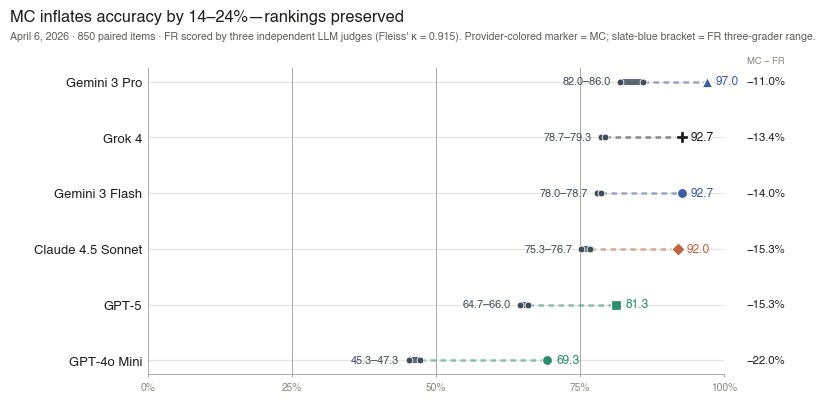

In [14]:
def plot_mc_vs_fr(t_mcfr):
    """Per-model MC accuracy + FR three-grader range.

    MC marker (per-model shape, provider color) sits on top of a slate-blue
    bracket spanning the FR range; gap printed in the right margin.
    """
    df = t_mcfr.sort_values("mc", ascending=False).copy()

    fig, ax = plt.subplots(figsize=(8.6, 4.2))
    y_idx = np.arange(len(df))[::-1]
    trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

    for yi, m in zip(y_idx, df.index):
        c     = PAL["provider"][PROVIDERS[m]]
        style = MODEL_STYLE[m]
        mc    = df.loc[m, "mc"]
        fr_lo = df.loc[m, "fr_lo"]
        fr_hi = df.loc[m, "fr_hi"]

        ax.plot([0, 100], [yi, yi], color=PAL["secondary"], linewidth=0.9,
                alpha=0.28, zorder=1)
        # FR range bracket in slate blue
        ax.plot([fr_lo, fr_hi], [yi, yi], color=PAL["accent_soft"], linewidth=4.4,
                alpha=0.85, solid_capstyle="butt", zorder=2)
        # Connector from FR range to MC
        ax.plot([fr_hi, mc], [yi, yi], color=c, linewidth=2.0,
                alpha=0.45, linestyle=(0,(2,1.6)), zorder=2)
        # Endpoints — small slate dots for FR low/high
        ax.scatter([fr_lo, fr_hi], [yi, yi], s=24, color=PAL["accent_soft"],
                   edgecolors="white", linewidths=0.6, zorder=3)
        # MC — large per-model marker
        ax.scatter([mc], [yi], s=style["size"]*2.2, color=c,
                   marker=style["marker"], edgecolors="white", linewidths=0.9, zorder=4)

        ax.text(mc + 1.6, yi, f"{mc:.1f}", va="center", ha="left",
                fontsize=8.6, color=c, fontweight="bold")
        ax.text(fr_lo - 1.6, yi, f"{fr_lo:.1f}–{fr_hi:.1f}",
                va="center", ha="right", fontsize=7.8,
                color=PAL["accent_soft"], fontweight="bold")
        gap = mc - fr_hi
        ax.text(1.04, yi, f"−{gap:.1f}%", transform=trans,
                ha="left", va="center", fontsize=8.2,
                fontweight="bold", color=PAL["text_main"])

    ax.text(1.04, len(df) - 0.7, "MC – FR", transform=trans,
            ha="left", va="bottom", fontsize=6.8, fontweight="bold",
            color=PAL["text_muted"])

    ax.set_yticks(y_idx)
    ax.set_yticklabels(df.index, fontsize=9.4, fontweight=600, color=PAL["text_main"])
    ax.tick_params(axis="y", length=0, pad=4)
    ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 25, 50, 75, 100]], fontsize=7.4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)

    fig.text(0.02, 0.97, "MC inflates accuracy by 14–24%—rankings preserved",
             fontsize=11.8, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.928,
             "April 6, 2026 · 850 paired items · FR scored by three independent LLM judges (Fleiss' κ = 0.915). "
             "Provider-colored marker = MC; slate-blue bracket = FR three-grader range.",
             fontsize=7.6, color=PAL["text_mid"])

    fig.subplots_adjust(left=0.18, right=0.85, top=0.86, bottom=0.13)
    savefig(fig, "fig_mc_vs_fr")
    plt.show()

plot_mc_vs_fr(t_mcfr)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_mcfr_per_region


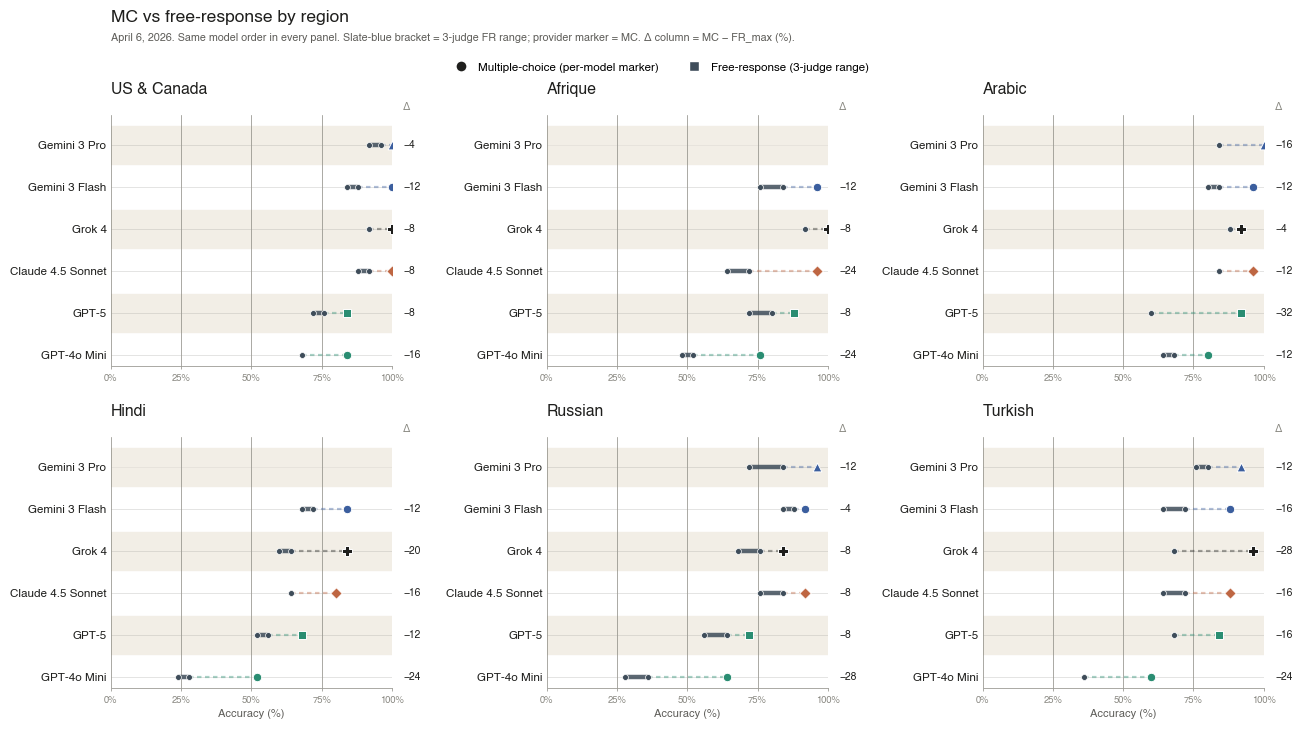

In [15]:
def plot_mcfr_per_region():
    """Six small-multiples: MC vs FR by model, faceted by region.

    Fixed model order across panels (sorted by overall MC accuracy) so y-tick
    labels never collide with the previous panel's Δ column.
    """
    overall_mc = (df_mc_paired.groupby("model")["is_correct"].mean()
                  .sort_values(ascending=False))
    fixed_order = [m for m in overall_mc.index if m in [n for n, _ in FR_MODELS]]

    fig = plt.figure(figsize=(13.0, 7.4))
    gs = fig.add_gridspec(2, 3, left=0.078, right=0.965, top=0.86, bottom=0.085,
                          wspace=0.55, hspace=0.28)
    axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]

    for ax, region in zip(axes, REGION_NAMES):
        y_idx = np.arange(len(fixed_order))[::-1]

        for yi in y_idx[::2]:
            ax.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)

        trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

        for yi, m in zip(y_idx, fixed_order):
            mc = df_mc_paired[(df_mc_paired["model"]==m) & (df_mc_paired["region"]==region)]["is_correct"].mean()
            fr = (df_fr_paired[(df_fr_paired["model"]==m) & (df_fr_paired["region"]==region)]
                  .groupby("judge")["is_correct"].mean())
            if np.isnan(mc) or len(fr) == 0:
                # Leave row blank but still draw the reference track for alignment.
                ax.plot([0, 100], [yi, yi], color=PAL["secondary"],
                        linewidth=0.5, alpha=0.18, zorder=1)
                continue
            mc *= 100; fl = fr.min() * 100; fh = fr.max() * 100
            c     = PAL["provider"][PROVIDERS[m]]
            style = MODEL_STYLE[m]

            ax.plot([0, 100], [yi, yi], color=PAL["secondary"],
                    linewidth=0.7, alpha=0.28, zorder=1)
            ax.plot([fl, fh], [yi, yi], color=PAL["accent_soft"],
                    linewidth=3.2, alpha=0.85, solid_capstyle="butt", zorder=2)
            ax.plot([fh, mc], [yi, yi], color=c, linewidth=1.6,
                    alpha=0.40, linestyle=(0,(2,1.6)), zorder=2)
            ax.scatter([fl, fh], [yi, yi], s=18, color=PAL["accent_soft"],
                       edgecolors="white", linewidths=0.5, zorder=3)
            ax.scatter([mc], [yi], s=style["size"]*1.55, color=c,
                       marker=style["marker"], edgecolors="white",
                       linewidths=0.7, zorder=4)
            ax.text(1.04, yi, f"−{mc-fh:.0f}", transform=trans,
                    ha="left", va="center", fontsize=7.4,
                    fontweight="bold", color=PAL["text_main"])

        # Δ header — blended transform.
        ax.text(1.04, len(fixed_order) - 0.2, "Δ", transform=trans,
                ha="left", va="bottom", fontsize=7.4, fontweight="bold",
                color=PAL["text_muted"])

        ax.set_yticks(y_idx)
        ax.set_yticklabels(fixed_order, fontsize=8.4, fontweight=600,
                           color=PAL["text_main"])
        ax.tick_params(axis="y", length=0, pad=3)
        ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_xticklabels([f"{x}%" for x in [0, 25, 50, 75, 100]], fontsize=6.8)
        ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
        ax.set_axisbelow(True); clean_spines(ax)
        ax.text(0.0, 1.07, region, transform=ax.transAxes,
                fontsize=11.4, fontweight="bold", color=PAL["text_main"],
                ha="left", va="bottom")

    for ax in axes[3:]:
        ax.set_xlabel("Accuracy (%)", fontsize=8.0, color=PAL["text_mid"], labelpad=3)

    handles = [
        plt.Line2D([0],[0], marker="o", linestyle="", color=PAL["text_main"],
                   markeredgecolor="white", markersize=8, label="Multiple-choice (per-model marker)"),
        plt.Line2D([0],[0], marker="s", linestyle="", color=PAL["accent_soft"],
                   markeredgecolor="white", markersize=7, label="Free-response (3-judge range)"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.945),
               ncol=2, frameon=False, fontsize=8.4,
               handletextpad=0.45, columnspacing=2.0)

    fig.text(0.078, 0.985, "MC vs free-response by region",
             fontsize=12.5, fontweight="bold", color=PAL["text_main"])
    fig.text(0.078, 0.96,
             "April 6, 2026. Same model order in every panel. "
             "Slate-blue bracket = 3-judge FR range; provider marker = MC. Δ column = MC − FR_max (%).",
             fontsize=7.8, color=PAL["text_mid"])
    savefig(fig, "fig_mcfr_per_region")
    plt.show()

plot_mcfr_per_region()


### 4a. MC ↔ FR gap heatmap (model × region)

The per-region small-multiples answer "where does MC over-state accuracy?" qualitatively. The
heatmap below answers it quantitatively: each cell is **MC − FR_max** (pp) for that
(model, region) pair, so larger numbers = bigger over-statement. Sequential palette since the
gap is one-sided (MC ≥ FR almost everywhere).

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_mcfr_gap_heatmap


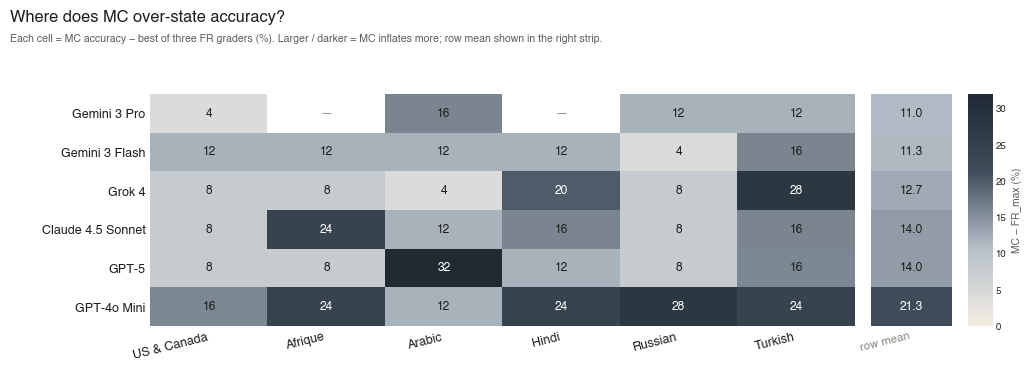

In [16]:
def plot_mcfr_gap_heatmap():
    """model × region matrix of MC − FR_max in percentage points.

    Layout: [heatmap] | [row-mean column] | [colorbar] — three explicit axes so the
    row-mean text never collides with the colorbar tick labels.
    """
    overall_mc = (df_mc_paired.groupby("model")["is_correct"].mean()
                  .sort_values(ascending=False))
    fixed_order = [m for m in overall_mc.index if m in [n for n, _ in FR_MODELS]]

    grid = np.full((len(fixed_order), len(REGION_NAMES)), np.nan)
    for i_m, m in enumerate(fixed_order):
        for j_r, region in enumerate(REGION_NAMES):
            mc = df_mc_paired[(df_mc_paired["model"]==m) & (df_mc_paired["region"]==region)]["is_correct"].mean()
            fr_max = (df_fr_paired[(df_fr_paired["model"]==m) & (df_fr_paired["region"]==region)]
                      .groupby("judge")["is_correct"].mean().max())
            if not (np.isnan(mc) or np.isnan(fr_max)):
                grid[i_m, j_r] = (mc - fr_max) * 100

    fig = plt.figure(figsize=(10.4, 4.0))
    gs  = fig.add_gridspec(1, 3, width_ratios=[28, 3.2, 1.0],
                           left=0.155, right=0.965, top=0.78, bottom=0.20,
                           wspace=0.06)
    ax_h = fig.add_subplot(gs[0, 0])
    ax_r = fig.add_subplot(gs[0, 1], sharey=ax_h)
    cax  = fig.add_subplot(gs[0, 2])

    cmap = LinearSegmentedColormap.from_list(
        "deck_sequential", ["#F2EDE3", "#B7C0C9", PAL["accent_soft"], "#1F2A33"]
    )
    vmax = float(np.nanmax(np.abs(grid)))
    im   = ax_h.imshow(grid, cmap=cmap, vmin=0, vmax=vmax, aspect="auto")

    for i_m in range(len(fixed_order)):
        for j_r in range(len(REGION_NAMES)):
            v = grid[i_m, j_r]
            if np.isnan(v):
                ax_h.text(j_r, i_m, "—", ha="center", va="center",
                          fontsize=8.4, color=PAL["text_muted"], fontweight=600)
                continue
            shade = v / vmax if vmax > 0 else 0
            color = "white" if shade > 0.55 else PAL["text_main"]
            ax_h.text(j_r, i_m, f"{v:.0f}", ha="center", va="center",
                      fontsize=8.6, color=color, fontweight=600)

    ax_h.set_xticks(range(len(REGION_NAMES)))
    ax_h.set_xticklabels(REGION_NAMES, fontsize=9.0, fontweight=600,
                         color=PAL["text_main"], rotation=14, ha="right")
    ax_h.set_yticks(range(len(fixed_order)))
    ax_h.set_yticklabels(fixed_order, fontsize=9.0, fontweight=600, color=PAL["text_main"])
    for s in ("top", "right", "left", "bottom"): ax_h.spines[s].set_visible(False)
    ax_h.tick_params(axis="x", length=0); ax_h.tick_params(axis="y", length=0)

    # Row-mean strip (its own axis).
    row_avg = np.nanmean(grid, axis=1)
    avg_grid = row_avg.reshape(-1, 1)
    ax_r.imshow(avg_grid, cmap=cmap, vmin=0, vmax=vmax, aspect="auto")
    for i_m, v in enumerate(row_avg):
        shade = v / vmax if vmax > 0 else 0
        color = "white" if shade > 0.55 else PAL["text_main"]
        ax_r.text(0, i_m, f"{v:.1f}", ha="center", va="center",
                  fontsize=8.6, color=color, fontweight="bold")
    ax_r.set_xticks([0]); ax_r.set_xticklabels(["row mean"], fontsize=8.4,
                                                fontweight=600, color=PAL["text_muted"],
                                                rotation=14, ha="right")
    ax_r.tick_params(axis="x", length=0); ax_r.tick_params(axis="y", length=0)
    plt.setp(ax_r.get_yticklabels(), visible=False)
    for s in ("top", "right", "left", "bottom"): ax_r.spines[s].set_visible(False)

    cb = fig.colorbar(im, cax=cax)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=7.0, length=0, pad=2)
    cb.set_label("MC − FR_max (%)", fontsize=7.4, color=PAL["text_mid"], labelpad=4)

    fig.text(0.02, 0.96, "Where does MC over-state accuracy?",
             fontsize=11.8, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.91,
             "Each cell = MC accuracy − best of three FR graders (%). "
             "Larger / darker = MC inflates more; row mean shown in the right strip.",
             fontsize=7.6, color=PAL["text_mid"])
    savefig(fig, "fig_mcfr_gap_heatmap")
    plt.show()

plot_mcfr_gap_heatmap()


## 5. Bonus &mdash; One-month-after temporal decay

The repository also contains `ablation/extra_one_month_after_results/`: the
same Feb 9–12 question batch re-run thirty days later (March 9, 2026) on the
four frontier models, across all six regions. We surface it here as an
additional ablation.


In [17]:
ONEMONTH_DAYS = [f"february_{d}" for d in [9, 10, 11, 12]]
ONEMONTH_MODELS = [m for m, _ in ADV_MODELS]   # same 4 frontier models

def build_onemonth_records():
    for region in [r for r,_ in REGIONS]:
        for label, dir_ in ADV_MODELS:
            for d in ONEMONTH_DAYS:
                # same-day (production) run
                same = load_jsonl(RES / region / dir_ / f"{d}_outputs.jsonl")
                for q_idx, row in enumerate(same):
                    pred = extract_answer(row.get("model_output"))
                    gold = gold_letter(row, region_dir=region, day=d, q_idx=q_idx)
                    yield dict(model=label, region=REGION_DIR_TO_NAME[region],
                               day=d, q_idx=q_idx, condition="same_day",
                               is_correct=is_correct_pred(pred, gold))
                later = load_jsonl(ABL / "extra_one_month_after_results" / region / dir_ /
                                    f"{d}_outputs_eval_on_march9.jsonl")
                for q_idx, row in enumerate(later):
                    pred = extract_answer(row.get("model_output"))
                    # +30-day re-run uses same gold as the original day's question.
                    gold = gold_letter(row, region_dir=region, day=d, q_idx=q_idx)
                    yield dict(model=label, region=REGION_DIR_TO_NAME[region],
                               day=d, q_idx=q_idx, condition="month_later",
                               is_correct=is_correct_pred(pred, gold))

df_om = pd.DataFrame(build_onemonth_records())
print(f"one-month-after rows: {len(df_om):,}")

# Aggregate accuracy table.
#
# Sign convention: Δ = month_later − same_day, so *negative* Δ means decay
# (the model lost accuracy at +30 days) and *positive* Δ means improvement.
# This matches the convention used by the heatmap and dumbbell figures
# below; previously the table used the opposite sign, which made the table
# disagree with the figures by a leading minus sign.
om_table = (df_om.groupby(["model", "condition"])["is_correct"].mean() * 100).unstack("condition")
om_table["delta"] = om_table["month_later"] - om_table["same_day"]
om_table = om_table[["same_day", "month_later", "delta"]].round(2)
om_table.columns = ["Same-day acc. (%)", "+30-day acc. (%)", "Δ (pp, +30d − same-day)"]
om_table = om_table.loc[ONEMONTH_MODELS]
display(om_table)

one-month-after rows: 4,800


,Same-day acc. (%),+30-day acc. (%),"Δ (pp, +30d − same-day)"
model,,,
Grok 4,95.00,94.67,-0.33
Gemini 3 Pro,92.67,95.50,2.83
Claude 4.5 Sonnet,89.67,90.50,0.83
GPT-5,85.17,85.50,0.33


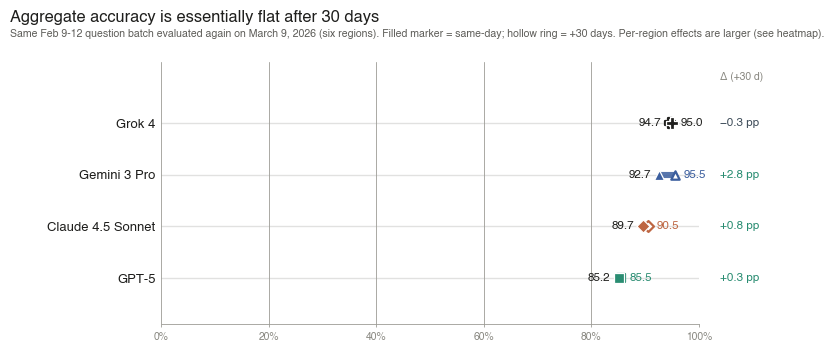

In [18]:
def plot_onemonth_decay():
    """Same-day → +30-day dumbbell. Provider color, per-model shape,
    sign-aware Δ column (slate blue if negative, anthropic terracotta if positive)."""
    fig, ax = plt.subplots(figsize=(8.4, 3.6))

    rows = [(m,
             df_om[(df_om["model"]==m) & (df_om["condition"]=="same_day"   )]["is_correct"].mean()*100,
             df_om[(df_om["model"]==m) & (df_om["condition"]=="month_later")]["is_correct"].mean()*100)
            for m in ONEMONTH_MODELS]
    rows.sort(key=lambda r: r[1], reverse=True)

    y_idx = np.arange(len(rows))[::-1]
    trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

    for yi, (m, s, l) in zip(y_idx, rows):
        c     = PAL["provider"][PROVIDERS[m]]
        style = MODEL_STYLE[m]
        delta = l - s

        ax.plot([0, 100], [yi, yi], color=PAL["secondary"], linewidth=1.0, alpha=0.30, zorder=1)
        ax.plot([s, l], [yi, yi], color=c, linewidth=4.4, alpha=0.85,
                solid_capstyle="butt", zorder=2)

        ax.scatter([s], [yi], s=style["size"]*2.0, color=c,
                   marker=style["marker"], edgecolors="white", linewidths=0.9, zorder=4)
        ax.scatter([l], [yi], s=style["size"]*1.40, facecolors="white",
                   edgecolors=c, marker=style["marker"], linewidths=1.6, zorder=3)

        # Numeric labels — place left/right depending on which side is larger.
        if l < s:
            ax.text(l - 1.6, yi, f"{l:.1f}", ha="right", va="center",
                    fontsize=8.4, color=c, fontweight="bold")
            ax.text(s + 1.6, yi, f"{s:.1f}", ha="left", va="center",
                    fontsize=8.4, color=PAL["text_main"], fontweight="bold")
        else:
            ax.text(s - 1.6, yi, f"{s:.1f}", ha="right", va="center",
                    fontsize=8.4, color=PAL["text_main"], fontweight="bold")
            ax.text(l + 1.6, yi, f"{l:.1f}", ha="left", va="center",
                    fontsize=8.4, color=c, fontweight="bold")

        sign  = "+" if delta >= 0 else "−"
        d_col = PAL["provider"]["openai"] if delta >= 0 else PAL["accent_soft"]
        ax.text(1.04, yi, f"{sign}{abs(delta):.1f} pp", transform=trans,
                ha="left", va="center", fontsize=8.4, fontweight="bold", color=d_col)

    ax.text(1.04, len(rows) - 0.2, "Δ (+30 d)", transform=trans,
            ha="left", va="bottom", fontsize=7.4, fontweight="bold", color=PAL["text_muted"])

    ax.set_yticks(y_idx)
    ax.set_yticklabels([m for m, *_ in rows], fontsize=9.4, fontweight=600,
                       color=PAL["text_main"])
    ax.tick_params(axis="y", length=0, pad=4)
    ax.set_xlim(0, 100); ax.set_ylim(-0.9, len(rows) + 0.2)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 20, 40, 60, 80, 100]], fontsize=7.4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)

    fig.text(0.02, 0.97,
             "Aggregate accuracy is essentially flat after 30 days",
             fontsize=11.8, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.928,
             "Same Feb 9-12 question batch evaluated again on March 9, 2026 (six regions). "
             "Filled marker = same-day; hollow ring = +30 days. Per-region effects are larger (see heatmap).",
             fontsize=7.6, color=PAL["text_mid"])

    fig.subplots_adjust(left=0.20, right=0.84, top=0.86, bottom=0.13)
    # orphan figure (not used in manuscript) — disabled by cleanup
    # savefig(fig, "fig_onemonth_decay")
    plt.show()

plot_onemonth_decay()


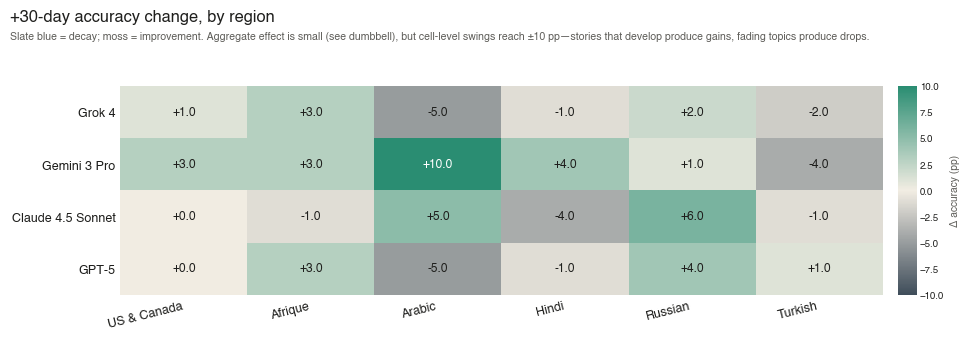

In [19]:
def plot_onemonth_decay_by_region():
    """Δ (+30-day acc − same-day acc) heatmap, model × region.

    Diverging palette: slate-blue (decay) → cream (no change) → muted moss (improvement),
    matching the provenance-deck accents used throughout the deck.
    """
    delta = (df_om.groupby(["model","region","condition"])["is_correct"].mean().unstack("condition")
                    .assign(delta=lambda d: (d["month_later"] - d["same_day"]) * 100)
                    ["delta"].unstack("region").reindex(ONEMONTH_MODELS)[REGION_NAMES])

    fig = plt.figure(figsize=(9.6, 3.6))
    gs  = fig.add_gridspec(1, 2, width_ratios=[40, 1],
                           left=0.135, right=0.965, top=0.78, bottom=0.20,
                           wspace=0.04)
    ax  = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    cmap = LinearSegmentedColormap.from_list(
        "deck_diverging",
        [PAL["accent_soft"], "#F2EDE3", PAL["provider"]["openai"]],
    )
    vmax = float(np.ceil(np.abs(delta.values).max()))
    im   = ax.imshow(delta.values, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

    for i_m, m in enumerate(ONEMONTH_MODELS):
        for j_r, r in enumerate(REGION_NAMES):
            v = delta.iloc[i_m, j_r]
            shade = abs(v) / vmax if vmax > 0 else 0
            color = "white" if shade > 0.60 else PAL["text_main"]
            ax.text(j_r, i_m, f"{v:+.1f}", ha="center", va="center",
                    fontsize=8.6, color=color, fontweight=600)

    ax.set_xticks(range(len(REGION_NAMES)))
    ax.set_xticklabels(REGION_NAMES, fontsize=9.0, fontweight=600,
                       color=PAL["text_main"], rotation=14, ha="right")
    ax.set_yticks(range(len(ONEMONTH_MODELS)))
    ax.set_yticklabels(ONEMONTH_MODELS, fontsize=9.0, fontweight=600,
                       color=PAL["text_main"])
    for s in ("top", "right", "left", "bottom"): ax.spines[s].set_visible(False)
    ax.tick_params(axis="x", length=0); ax.tick_params(axis="y", length=0)

    cb = fig.colorbar(im, cax=cax)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=7.0, length=0, pad=2)
    cb.set_label("Δ accuracy (pp)", fontsize=7.4, color=PAL["text_mid"], labelpad=4)

    fig.text(0.02, 0.96, "+30-day accuracy change, by region",
             fontsize=11.8, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.91,
             "Slate blue = decay; moss = improvement. Aggregate effect is small (see dumbbell), "
             "but cell-level swings reach ±10 pp—stories that develop produce gains, fading topics produce drops.",
             fontsize=7.6, color=PAL["text_mid"])
    # orphan figure (not used in manuscript) — disabled by cleanup
    # savefig(fig, "fig_onemonth_decay_heatmap")
    plt.show()

plot_onemonth_decay_by_region()


## 6. Three-panel splash &mdash; ablations at a glance

A single 3-panel summary: the search ablation (left), the MC$\,\leftrightarrow\,$FR gap (middle),
and the adversarial collapse (right).


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_ablation_splash


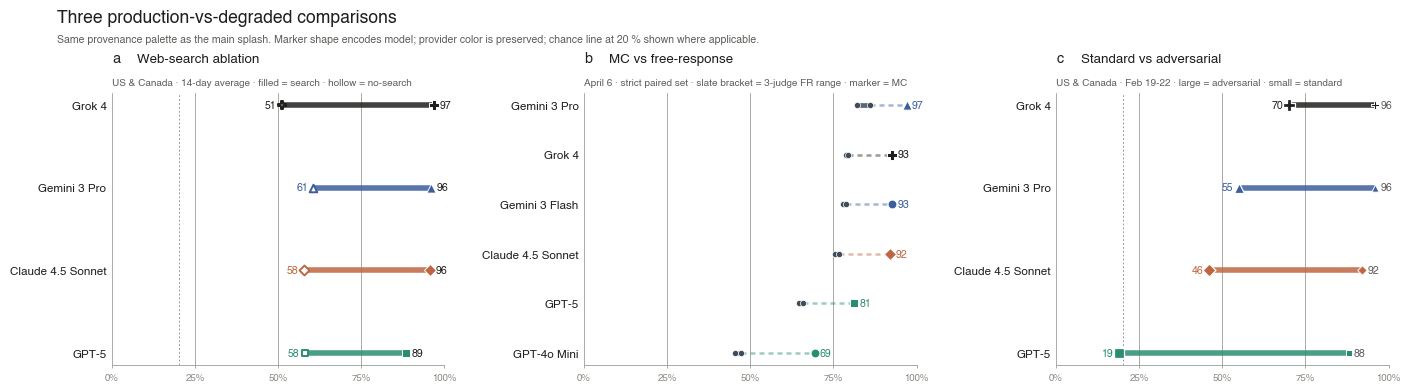

In [20]:
def plot_ablation_splash():
    """Three-panel splash: (a) search vs no-search, (b) MC vs FR, (c) standard vs adversarial."""
    fig = plt.figure(figsize=(13.8, 4.4))
    gs  = fig.add_gridspec(1, 3, left=0.06, right=0.985, top=0.78, bottom=0.16,
                           wspace=0.42)
    ax_a, ax_b, ax_c = (fig.add_subplot(gs[0, k]) for k in range(3))

    def style_axis(ax):
        ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_xticklabels([f"{x}%" for x in [0, 25, 50, 75, 100]], fontsize=7.0)
        ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
        ax.set_axisbelow(True); clean_spines(ax)
        ax.tick_params(axis="y", length=0, pad=4)

    def panel_title(ax, letter, title, subtitle):
        ax.text(0.0, 1.10, letter, transform=ax.transAxes,
                fontsize=10.4, fontweight="bold", fontstyle="italic",
                color=PAL["text_main"], ha="left", va="bottom")
        ax.text(0.075, 1.10, title, transform=ax.transAxes,
                fontsize=9.6, fontweight="bold",
                color=PAL["text_main"], ha="left", va="bottom")
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=7.2, color=PAL["text_mid"], ha="left", va="bottom")

    # ───── Panel A: search vs no-search (US&Canada, Feb 19-22) ────
    full_window = [f"february_{d}" for d in range(9, 23)]
    sub = df_abl[df_abl["day"].isin(full_window)]
    rows_a = []
    for m in ABLATION_MODELS:
        ms = sub[sub["model"] == m]
        rows_a.append((m,
                       ms[ms["condition"]=="search"   ]["is_correct"].mean()*100,
                       ms[ms["condition"]=="no_search"]["is_correct"].mean()*100))
    rows_a.sort(key=lambda r: r[1], reverse=True)
    y = np.arange(len(rows_a))[::-1]
    for yi, (m, s, n) in zip(y, rows_a):
        c = PAL["provider"][PROVIDERS[m]]
        st = MODEL_STYLE[m]
        ax_a.plot([n, s], [yi, yi], color=c, linewidth=4.0, alpha=0.85,
                  solid_capstyle="butt", zorder=2)
        ax_a.scatter([s], [yi], s=st["size"]*1.7, color=c, marker=st["marker"],
                     edgecolors="white", linewidths=0.7, zorder=4)
        ax_a.scatter([n], [yi], s=st["size"]*1.15, facecolors="white", edgecolors=c,
                     marker=st["marker"], linewidths=1.4, zorder=3)
        ax_a.text(s + 1.6, yi, f"{s:.0f}", ha="left", va="center",
                  fontsize=7.6, color=PAL["text_main"], fontweight="bold")
        ax_a.text(n - 1.6, yi, f"{n:.0f}", ha="right", va="center",
                  fontsize=7.6, color=c, fontweight="bold")
    ax_a.set_yticks(y)
    ax_a.set_yticklabels([m for m, *_ in rows_a], fontsize=8.4, fontweight=600,
                         color=PAL["text_main"])
    style_axis(ax_a)
    ax_a.axvline(20, color=PAL["accent_soft"], linewidth=0.7, linestyle=(0,(2,2)),
                 alpha=0.55, zorder=0)
    panel_title(ax_a, "a", "Web-search ablation",
                "US & Canada · 14-day average · filled = search · hollow = no-search")

    # ───── Panel B: MC vs FR (April 6) ─────────────────────────────────────────
    # Use the strict paired denominator (df_mc_paired / df_fr_paired) so this
    # panel reports the same MC/FR coverage as every other MC↔FR figure in
    # the notebook. Earlier versions used df_mc / df_fr, which silently
    # included Gemini 3 Pro's partial-coverage cells and produced a number
    # that disagreed with the main MC↔FR plot.
    rows_b = []
    for m, _ in FR_MODELS:
        mc_sub = df_mc_paired[df_mc_paired["model"]==m]
        fr_sub = df_fr_paired[df_fr_paired["model"]==m]
        if mc_sub.empty or fr_sub.empty:
            continue  # excluded from strict paired set
        mc = mc_sub["is_correct"].mean() * 100
        fr = fr_sub.groupby("judge")["is_correct"].mean() * 100
        rows_b.append((m, mc, fr.min(), fr.max()))
    rows_b.sort(key=lambda r: -r[1])
    y = np.arange(len(rows_b))[::-1]
    for yi, (m, mc, fl, fh) in zip(y, rows_b):
        c = PAL["provider"][PROVIDERS[m]]
        st = MODEL_STYLE[m]
        ax_b.plot([fl, fh], [yi, yi], color=PAL["accent_soft"], linewidth=3.4,
                  alpha=0.85, solid_capstyle="butt", zorder=2)
        ax_b.plot([fh, mc], [yi, yi], color=c, linewidth=1.8, alpha=0.45,
                  linestyle=(0,(2,1.6)), zorder=2)
        ax_b.scatter([fl, fh], [yi, yi], s=20, color=PAL["accent_soft"],
                     edgecolors="white", linewidths=0.5, zorder=3)
        ax_b.scatter([mc], [yi], s=st["size"]*1.7, color=c, marker=st["marker"],
                     edgecolors="white", linewidths=0.7, zorder=4)
        ax_b.text(mc + 1.6, yi, f"{mc:.0f}", ha="left", va="center",
                  fontsize=7.6, color=c, fontweight="bold")
    ax_b.set_yticks(y)
    ax_b.set_yticklabels([m for m, *_ in rows_b], fontsize=8.4, fontweight=600,
                         color=PAL["text_main"])
    style_axis(ax_b)
    panel_title(ax_b, "b", "MC vs free-response",
                "April 6 · strict paired set · slate bracket = 3-judge FR range · marker = MC")

    # ───── Panel C: standard vs adversarial ────────────────────────────────────
    rows_c = []
    for m, _ in ADV_MODELS:
        s_acc = df_std[df_std["model"]==m]["is_correct"].mean() * 100
        a_acc = df_adv[df_adv["model"]==m]["is_correct"].mean() * 100
        rows_c.append((m, s_acc, a_acc))
    rows_c.sort(key=lambda r: -r[2])
    y = np.arange(len(rows_c))[::-1]
    for yi, (m, s, a) in zip(y, rows_c):
        c = PAL["provider"][PROVIDERS[m]]
        st = MODEL_STYLE[m]
        ax_c.plot([a, s], [yi, yi], color=c, linewidth=4.0, alpha=0.85,
                  solid_capstyle="butt", zorder=2)
        ax_c.scatter([s], [yi], s=st["size"]*1.05, color=c, marker=st["marker"],
                     edgecolors="white", linewidths=0.7, zorder=3)
        ax_c.scatter([a], [yi], s=st["size"]*2.0, color=c, marker=st["marker"],
                     edgecolors="white", linewidths=0.9, zorder=4)
        ax_c.text(s + 1.6, yi, f"{s:.0f}", ha="left", va="center",
                  fontsize=7.6, color=PAL["text_mid"], fontweight="bold")
        ax_c.text(a - 1.6, yi, f"{a:.0f}", ha="right", va="center",
                  fontsize=7.6, color=c, fontweight="bold")
    ax_c.set_yticks(y)
    ax_c.set_yticklabels([m for m, *_ in rows_c], fontsize=8.4, fontweight=600,
                         color=PAL["text_main"])
    style_axis(ax_c)
    ax_c.axvline(20, color=PAL["accent_soft"], linewidth=0.7, linestyle=(0,(2,2)),
                 alpha=0.55, zorder=0)
    panel_title(ax_c, "c", "Standard vs adversarial",
                "US & Canada · Feb 19-22 · large = adversarial · small = standard")

    fig.text(0.02, 0.94, "Three production-vs-degraded comparisons",
             fontsize=12.6, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.895,
             "Same provenance palette as the main splash. Marker shape encodes model; "
             "provider color is preserved; chance line at 20 % shown where applicable.",
             fontsize=7.6, color=PAL["text_mid"])

    savefig(fig, "fig_ablation_splash")
    plt.show()

plot_ablation_splash()
